In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import joblib
from imblearn.over_sampling import SMOTENC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import optuna
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
from optuna.visualization import plot_terminator_improvement
from optuna.terminator import report_cross_validation_scores
from sklearn.feature_selection import RFECV
from tabulate import tabulate
import json
import matplotlib.pyplot as plt

In [2]:
bank= pd.read_csv("/kaggle/input/datasets/prahazra/final-bank-data/Final_bank_data.csv")

In [3]:
X_train, x_test,Y_train, y_test= train_test_split(bank.drop('Exited', axis=1), bank['Exited'], test_size=0.2, random_state=42)

In [4]:
columns= X_train.columns
categorical_cols= []
numerical_cols= []
for col in columns:
  if bank[col].dtype == 'object' or bank[col].dtype == 'category':
    categorical_cols.append(col)
  else:
    numerical_cols.append(col)

In [5]:
smote_nc = SMOTENC(categorical_features=categorical_cols, random_state=42)
X_train_resampled, Y_train_resampled = smote_nc.fit_resample(X_train, Y_train)

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('scaler', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

In [7]:
X_train_preprocessed = preprocessor.fit_transform(X_train_resampled)
x_test_preprocessed = preprocessor.transform(x_test)

In [8]:
joblib.dump(preprocessor, 'preprocessor.joblib')

['preprocessor.joblib']

In [9]:
LR= LogisticRegression(random_state= 42)
DT= DecisionTreeClassifier(random_state= 42)
RF= RandomForestClassifier(random_state = 42)
GB= GradientBoostingClassifier(random_state= 42)
XGB= XGBClassifier(random_state= 42)

In [10]:
LR.fit(X_train_preprocessed, Y_train_resampled)
DT.fit(X_train_preprocessed, Y_train_resampled)
RF.fit(X_train_preprocessed, Y_train_resampled)
GB.fit(X_train_preprocessed, Y_train_resampled)
XGB.fit(X_train_preprocessed, Y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [11]:
Models= {
    "Logistic Regression": LR,
    "Decision Tree": DT,
    "Random Forest": RF,
    "Gradient Boosting": GB,
    "XGBoost": XGB
}


performance= []
for name, model in Models.items():
    y_pred= model.predict(x_test_preprocessed)
    accuracy= accuracy_score(y_test, y_pred)
    performance.append([name, f"{accuracy * 100:.2f}%"])

headers= ['Model', 'Test Accuracy']
print(tabulate(performance, headers= headers, tablefmt= 'grid'))

+---------------------+-----------------+
| Model               | Test Accuracy   |
+=====================+=================+
| Logistic Regression | 81.60%          |
+---------------------+-----------------+
| Decision Tree       | 78.30%          |
+---------------------+-----------------+
| Random Forest       | 85.45%          |
+---------------------+-----------------+
| Gradient Boosting   | 85.25%          |
+---------------------+-----------------+
| XGBoost             | 85.70%          |
+---------------------+-----------------+


Since, Decision tree is significantly producing less accuracy so we will discard it from our study and we will continue with Random Forest, Gradient Boosting, and XGBoost along with the baseline Logistic Regression.

In [12]:
sampler= optuna.samplers.TPESampler(seed =42)

In [13]:
def objective_LR(trial):
    all_possible_solvers = ['liblinear', 'saga', 'newton-cg', 'lbfgs', 'sag', 'newton-cholesky']
    solver = trial.suggest_categorical('solver', all_possible_solvers)

    if solver == 'liblinear':
        penalty = trial.suggest_categorical('penalty_liblinear', ['l1', 'l2'])
    elif solver in ['newton-cg', 'lbfgs', 'sag', 'newton-cholesky']:
        penalty = trial.suggest_categorical('penalty_standard', ['l2', None])
    elif solver == 'saga':
        penalty = trial.suggest_categorical('penalty_saga', ['l1', 'l2', 'elasticnet', None])

    C = trial.suggest_float('C', 1e-5, 10.0, log=True)
    tolerance = trial.suggest_float('tol', 1e-5, 1e-3, log=True)
    max_iter = trial.suggest_int('max_iter', 100, 1000)

    params = {
        'penalty': penalty,
        'C': C,
        'tol': tolerance,
        'solver': solver,
        'max_iter': max_iter,
        'random_state': 42
    }

    if penalty == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)

    try:
        model = LogisticRegression(**params)
        scores = cross_val_score(model, X_train_preprocessed, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state= 42))
        report_cross_validation_scores(trial, scores)

        return np.mean(scores)

    except Exception as e:
        raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")

In [14]:
study_LR = optuna.create_study(direction="maximize", study_name= "Optimize_LR", sampler= sampler)
study_LR.optimize(objective_LR, n_trials=100, show_progress_bar=True)

[I 2026-05-28 12:02:31,130] A new study created in memory with name: Optimize_LR


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-28 12:02:31,578] Trial 0 finished with value: 0.7404812519704358 and parameters: {'solver': 'saga', 'penalty_saga': 'l2', 'C': 1.3289448722869181e-05, 'tol': 0.0008706020878304854, 'max_iter': 850}. Best is trial 0 with value: 0.7404812519704358.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means 

[I 2026-05-28 12:02:46,901] Trial 1 finished with value: 0.8549404994132394 and parameters: {'solver': 'sag', 'penalty_standard': None, 'C': 6.870101665590028e-05, 'tol': 3.8396292998041685e-05, 'max_iter': 430}. Best is trial 1 with value: 0.8549404994132394.


...

[I 2026-05-28 12:15:04,048] Trial 96 finished with value: 0.8548616974505847 and parameters: {'solver': 'sag', 'penalty_standard': None, 'C': 0.17631826031590003, 'tol': 1.5797402003700668e-05, 'max_iter': 189}. Best is trial 25 with value: 0.8551764102751325.
[I 2026-05-28 12:15:05,812] Trial 97 finished with value: 0.805617122704278 and parameters: {'solver': 'saga', 'penalty_saga': 'l2', 'C': 0.0013922147488247, 'tol': 2.565018218563414e-05, 'max_iter': 220}. Best is trial 25 with value: 0.8551764102751325.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means 

[I 2026-05-28 12:15:15,556] Trial 98 finished with value: 0.854940406595851 and parameters: {'solver': 'sag', 'penalty_standard': None, 'C': 6.714287326848403, 'tol': 1.1312801898165823e-05, 'max_iter': 270}. Best is trial 25 with value: 0.8551764102751325.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the

[I 2026-05-28 12:15:29,264] Trial 99 finished with value: 0.8547831120618362 and parameters: {'solver': 'sag', 'penalty_standard': None, 'C': 3.405984415125206, 'tol': 0.00014965680821433976, 'max_iter': 381}. Best is trial 25 with value: 0.8551764102751325.


In [15]:
fig= plot_terminator_improvement(study_LR, plot_error = True)
fig.show()

/tmp/ipykernel_16/3908929248.py:1: ExperimentalWarning: optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.
  fig= plot_terminator_improvement(study_LR, plot_error = True)
/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning: RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.
  improvement_evaluator = RegretBoundEvaluator()
/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning: CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.
  error_evaluator = CrossValidationErrorEvaluator()
100%|██████████| 100/100 [00:14<00:00,  6.70it/s]


In [16]:
def objective_RF(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 500), # Corrected parameter name
      'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']), # Corrected parameter name
      'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.5), # Corrected parameter name
      'bootstrap': trial.suggest_categorical('bootstrap', [True, False]), # Corrected parameter name
      'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None]), # Corrected parameter name
      'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.1), # Corrected parameter name
      'random_state': 42
  }

  max_features_option = trial.suggest_categorical('max_features_option', ['sqrt', 'log2', None, 'float']) # Corrected parameter name
  if max_features_option == 'float':
      params['max_features'] = trial.suggest_float('max_features_rf_float', 0.1, 1.0)
  else:
      params['max_features'] = max_features_option # Assign directly to 'max_features'



  try:
      model = RandomForestClassifier(**params)
      scores = cross_val_score(model, X_train_preprocessed, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True,random_state= 42))
      report_cross_validation_scores(trial, scores)

      return np.mean(scores)

  except Exception as e:
      raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")

In [17]:
study_RF = optuna.create_study(direction="maximize", study_name= "Optimize_RF", sampler= sampler)
study_RF.optimize(objective_RF, n_trials=100, show_progress_bar=True)

[I 2026-05-28 12:15:46,516] A new study created in memory with name: Optimize_RF


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-28 12:15:59,821] Trial 0 finished with value: 0.7643962399057224 and parameters: {'n_estimators': 293, 'criterion': 'entropy', 'min_impurity_decrease': 0.05502596226383838, 'bootstrap': False, 'class_weight': 'balanced_subsample', 'ccp_alpha': 0.05107473025775658, 'max_features_option': 'sqrt'}. Best is trial 0 with value: 0.7643962399057224.
[I 2026-05-28 12:16:14,998] Trial 1 finished with value: 0.5000786472670076 and parameters: {'n_estimators': 475, 'criterion': 'log_loss', 'min_impurity_decrease': 0.181814801189647, 'bootstrap': True, 'class_weight': 'balanced_subsample', 'ccp_alpha': 0.028484049437746763, 'max_features_option': 'log2'}. Best is trial 0 with value: 0.7643962399057224.
[I 2026-05-28 12:16:29,566] Trial 2 finished with value: 0.4999213527329925 and parameters: {'n_estimators': 175, 'criterion': 'gini', 'min_impurity_decrease': 0.2447263801387815, 'bootstrap': True, 'class_weight': 'balanced_subsample', 'ccp_alpha': 0.07282163486118597, 'max_features_opti

In [18]:
fig= plot_terminator_improvement(study_RF, plot_error = True)
fig.show()

/tmp/ipykernel_16/2361534508.py:1: ExperimentalWarning:

optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning:

RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning:

CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

 82%|████████▏ | 82/100 [00:11<00:03,  5.35it/s][W 2026-05-28 13:15:40,875] The optimization of kernel parameters failed: 
linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 1 is not positive-definite).
The default initial kernel parameters will be used instead.
100%

In [19]:
def objective_GB(trial):
  params = {
      'loss': trial.suggest_categorical('loss', ['log_loss', 'exponential']), # Corrected parameter name
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True), # Corrected parameter name
      'n_estimators': trial.suggest_int('n_estimators', 50, 500), # Corrected parameter name
      'criterion': trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error']), # Corrected parameter name
      'min_samples_split': trial.suggest_int('min_samples_split', 2, 20), # Corrected parameter name
      'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.5), # Corrected parameter name
      'max_depth': trial.suggest_int('max_depth', 1, 20), # Corrected parameter name
      'random_state': 42
  }

  max_features_option = trial.suggest_categorical('max_features_option', ['sqrt', 'log2', None, 'float']) # Corrected parameter name
  if max_features_option == 'float':
      params['max_features'] = trial.suggest_float('max_features_gb_float', 0.1, 1.0)
  else:
      params['max_features'] = max_features_option # Assign directly to 'max_features'



  try:
      model = GradientBoostingClassifier(**params)
      scores = cross_val_score(model, X_train_preprocessed, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True,random_state= 42))
      report_cross_validation_scores(trial, scores)

      return np.mean(scores)

  except Exception as e:
      raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")

In [20]:
study_GB = optuna.create_study(direction="maximize", study_name= "Optimize_GB", sampler = sampler)
study_GB.optimize(objective_GB, n_trials=100, show_progress_bar=True)

[I 2026-05-28 13:15:44,591] A new study created in memory with name: Optimize_GB


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-28 13:15:59,771] Trial 0 finished with value: 0.8952165630773049 and parameters: {'loss': 'exponential', 'learning_rate': 0.19088462590130242, 'n_estimators': 461, 'criterion': 'friedman_mse', 'min_samples_split': 17, 'min_impurity_decrease': 0.3249819653888826, 'max_depth': 15, 'max_features_option': 'log2'}. Best is trial 0 with value: 0.8952165630773049.
[I 2026-05-28 13:16:06,031] Trial 1 finished with value: 0.784219466095819 and parameters: {'loss': 'exponential', 'learning_rate': 0.011300329228083602, 'n_estimators': 259, 'criterion': 'friedman_mse', 'min_samples_split': 13, 'min_impurity_decrease': 0.015250124969524714, 'max_depth': 1, 'max_features_option': 'sqrt'}. Best is trial 0 with value: 0.8952165630773049.
[I 2026-05-28 13:16:08,042] Trial 2 finished with value: 0.4999213527329925 and parameters: {'loss': 'log_loss', 'learning_rate': 0.08319261221667239, 'n_estimators': 88, 'criterion': 'squared_error', 'min_samples_split': 12, 'min_impurity_decrease': 0.3187

In [21]:
fig= plot_terminator_improvement(study_GB, plot_error = True)
fig.show()

/tmp/ipykernel_16/2307288078.py:1: ExperimentalWarning:

optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning:

RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning:

CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

100%|██████████| 100/100 [00:13<00:00,  7.44it/s]


In [22]:
def objective_XGB(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 500), # Corrected parameter name
      'max_depth': trial.suggest_int('max_depth', 1, 20), # Corrected parameter name
      'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']), # Corrected parameter name
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True), # Corrected parameter name
      'booster': trial.suggest_categorical('booster', ['gbtree', 'gblinear', 'dart']), # Corrected parameter name
      'gamma': trial.suggest_float('gamma', 0.0, 0.5), # Corrected parameter name
      'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # Corrected parameter name
      'use_label_encoder': False, # Suppress warning
      'eval_metric': 'logloss', # Suppress warning
      'random_state': 42
  }



  try:
      model = XGBClassifier(**params)
      scores = cross_val_score(model, X_train_preprocessed, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True,random_state= 42))
      report_cross_validation_scores(trial, scores)

      return np.mean(scores)

  except Exception as e:
      raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")

In [23]:
study_XGB = optuna.create_study(direction="maximize", study_name= "Optimize_XGB", sampler= sampler)
study_XGB.optimize(objective_XGB, n_trials=100, show_progress_bar=True)

[I 2026-05-28 14:36:20,295] A new study created in memory with name: Optimize_XGB


  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[14:36:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[14:37:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[14:39:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[14:40:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[14:42:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




[I 2026-05-28 14:43:53,826] Trial 0 finished with value: 0.9003304299022972 and parameters: {'n_estimators': 457, 'max_depth': 11, 'grow_policy': 'depthwise', 'learning_rate': 0.21027923816150645, 'booster': 'dart', 'gamma': 0.04564333839306678, 'min_child_weight': 4}. Best is trial 0 with value: 0.9003304299022972.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[14:43:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[14:45:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[14:47:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[14:49:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[14:50:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




...

[I 2026-05-28 16:39:15,544] Trial 97 finished with value: 0.9052863215324276 and parameters: {'n_estimators': 272, 'max_depth': 6, 'grow_policy': 'depthwise', 'learning_rate': 0.06227335403772633, 'booster': 'dart', 'gamma': 0.2165870036401011, 'min_child_weight': 3}. Best is trial 92 with value: 0.9059940541181065.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[16:39:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[16:39:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[16:40:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[16:40:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[16:41:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




[I 2026-05-28 16:41:44,888] Trial 98 finished with value: 0.8724826454688254 and parameters: {'n_estimators': 272, 'max_depth': 2, 'grow_policy': 'depthwise', 'learning_rate': 0.06322562711239288, 'booster': 'dart', 'gamma': 0.18564575106211859, 'min_child_weight': 3}. Best is trial 92 with value: 0.9059940541181065.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[16:41:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[16:42:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[16:42:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[16:42:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[16:42:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




[I 2026-05-28 16:43:13,990] Trial 99 finished with value: 0.8883732298563837 and parameters: {'n_estimators': 210, 'max_depth': 3, 'grow_policy': 'depthwise', 'learning_rate': 0.07004796368560957, 'booster': 'dart', 'gamma': 0.19801137123632556, 'min_child_weight': 3}. Best is trial 92 with value: 0.9059940541181065.


In [24]:
fig= plot_terminator_improvement(study_XGB, plot_error = True)
fig.show()

/tmp/ipykernel_16/776746673.py:1: ExperimentalWarning:

optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning:

RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning:

CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

100%|██████████| 100/100 [00:15<00:00,  6.30it/s]


In [25]:
Model_names= ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']
Model_scores= [study_LR.best_trial.value, study_RF.best_trial.value, study_GB.best_trial.value, study_XGB.best_trial.value]
Model_params= [study_LR.best_trial.params, study_RF.best_trial.params, study_GB.best_trial.params, study_XGB.best_trial.params]
performance= pd.DataFrame({'Model': Model_names, 'Score': Model_scores, 'Parameters': Model_params})
performance[['Model', 'Score']]

,Model,Score
0,Logistic Regression,0.855176
1,Random Forest,0.847546
2,Gradient Boosting,0.906230
3,XGBoost,0.905994


From, these scores it is evident that we should choose Gradient Boosting and XGBoost for further analysis, since they significantly out performs Random Forest.

In [26]:
def save_params(prefix_name, params_dict):
    file_name= f"{prefix_name}.json"
    with open(file_name, "w") as f:
        json.dump(params_dict, f, indent= 4)
    print(f"Successfully saved to: {file_name}")

In [27]:
LR_params1= study_LR.best_params
save_params("LR_params1", LR_params1)
GB_params1= study_GB.best_params
save_params("GB_params1", GB_params1)
XGB_params1= study_XGB.best_params
save_params("XGB_params1", XGB_params1)

Successfully saved to: LR_params1.json
Successfully saved to: GB_params1.json
Successfully saved to: XGB_params1.json


# Recursive Feature Elimination

Now, that we have seen the model performance with all features, lets see if removing some of them degrades the model performance or not.

Optimal number of features: 26
Selected Features: ['onehot__Geography_Germany', 'onehot__Gender_Male', 'onehot__AgeGroup_Old', 'onehot__AgeGroup_Teenager', 'onehot__AgeGroup_Young', 'onehot__TenureRiskGroup_Mid_Stable', 'scaler__CreditScore', 'scaler__Age', 'scaler__Tenure', 'scaler__Balance', 'scaler__NumOfProducts', 'scaler__HasCrCard', 'scaler__IsActiveMember', 'scaler__HasMultipleProduct', 'scaler__BalanceSalaryRatio', 'scaler__TenureAgeRatio', 'scaler__CreditScoreAgeRatio', 'scaler__AgeBalanceInteraction', 'scaler__ProductDensity', 'scaler__LoyalityScore', 'scaler__MidTierDanger', 'scaler__GermanPassiveWealth', 'scaler__BalancePerProduct', 'scaler__CardButInactive', 'scaler__CardAndActive', 'scaler__Female_Germany']


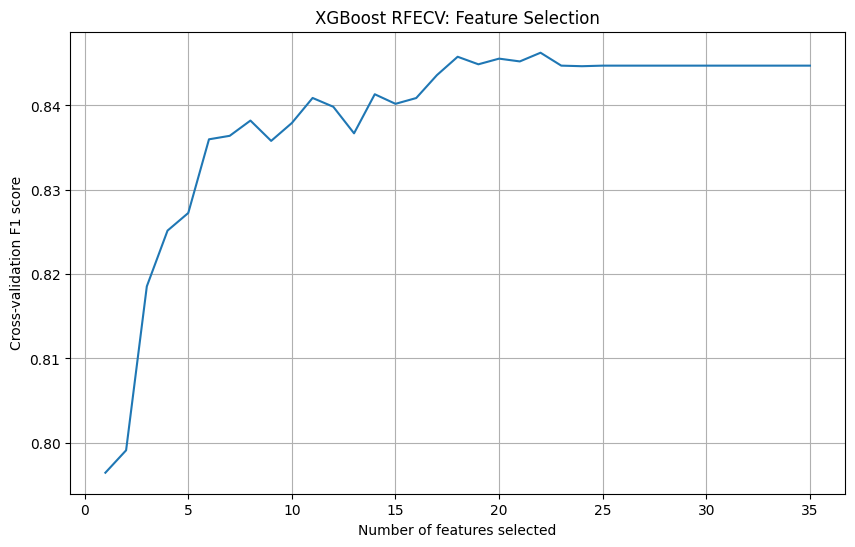

In [28]:
estimator = GradientBoostingClassifier(
    n_estimators=50,       # Keep tree count low for speed during selection
    max_depth=3,           # Shallow trees prevent overfitting during this phase
    learning_rate=0.1,
    random_state=42        # Ensures reproducible feature selection
)

# 2. Initialize RFECV
cv = StratifiedKFold(n_splits=5)
selector = RFECV(
    estimator=estimator,
    step=1,               # Remove 1 feature at a time
    cv=cv,
    scoring='f1',         # Metric suited for imbalanced data like churn
    min_features_to_select=5,
    n_jobs=-1
)

# 3. Fit the selector
selector = selector.fit(X_train_preprocessed, Y_train_resampled)

# 4. Extract optimal features
optimal_num_features = selector.n_features_

# Get feature names after preprocessing
preprocessed_feature_names = preprocessor.get_feature_names_out()

# Use the boolean mask from RFECV to select the corresponding feature names
selected_features = preprocessed_feature_names[selector.support_]

print(f"Optimal number of features: {optimal_num_features}")
print(f"Selected Features: {list(selected_features)}")

# 5. Filter your datasets to include only the selected features
X_train_rfe = selector.transform(X_train_preprocessed)
X_test_rfe = selector.transform(x_test_preprocessed)

# Optional: Plot the results to see the performance curve
plt.figure(figsize=(10, 6))
plt.title("XGBoost RFECV: Feature Selection")
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation F1 score")
plt.plot(range(1, len(selector.cv_results_['mean_test_score']) + 1), selector.cv_results_['mean_test_score'])
plt.grid(True)
plt.show()

In [29]:
model1 = LogisticRegression(random_state=42, max_iter=1000)
model2 = RandomForestClassifier(random_state=42, n_estimators=100)
model3 = GradientBoostingClassifier(random_state=42, n_estimators=100) # Full model

# 2. Train (Fit) the fresh models on the RFE-selected training data
model1.fit(X_train_rfe, Y_train_resampled)
model2.fit(X_train_rfe, Y_train_resampled)
model3.fit(X_train_rfe, Y_train_resampled)

# 3. Store the newly trained models in a dictionary
New_Models = {
    "Logistic Regression (RFE)": model1,
    "Random Forest (RFE)": model2,
    "Gradient Boosting (RFE)": model3
}

# 4. Loop through and evaluate using the RFE-selected test data
performance = []
for name, model in New_Models.items():
    # Use X_test_rfe to match the expected feature count
    y_pred = model.predict(X_test_rfe)
    
    accuracy = accuracy_score(y_test, y_pred)
    performance.append([name, f"{accuracy * 100:.2f}%"])

# 5. Print your clean results table
print(tabulate(performance, headers=["Model Name", "Test Accuracy"], tablefmt="grid"))

+---------------------------+-----------------+
| Model Name                | Test Accuracy   |
+===========================+=================+
| Logistic Regression (RFE) | 81.40%          |
+---------------------------+-----------------+
| Random Forest (RFE)       | 85.30%          |
+---------------------------+-----------------+
| Gradient Boosting (RFE)   | 84.95%          |
+---------------------------+-----------------+


In [30]:
def objective_LR2(trial):
    # 1. Nest the penalty choice based on compatible solvers
    all_possible_solvers = ['liblinear', 'saga', 'newton-cg', 'lbfgs', 'sag', 'newton-cholesky']
    solver = trial.suggest_categorical('solver', all_possible_solvers)

    if solver == 'liblinear':
        penalty = trial.suggest_categorical('penalty_liblinear', ['l1', 'l2'])
    elif solver in ['newton-cg', 'lbfgs', 'sag', 'newton-cholesky']:
        penalty = trial.suggest_categorical('penalty_standard', ['l2', None])
    elif solver == 'saga':
        penalty = trial.suggest_categorical('penalty_saga', ['l1', 'l2', 'elasticnet', None])

    # 2. Extract standard hyperparameters
    C = trial.suggest_float('C', 1e-5, 10.0, log=True)
    tolerance = trial.suggest_float('tol', 1e-5, 1e-3, log=True)
    max_iter = trial.suggest_int('max_iter', 100, 1000)

    params = {
        'penalty': penalty,
        'C': C,
        'tol': tolerance,
        'solver': solver,
        'max_iter': max_iter,
        'random_state': 42
    }

    if penalty == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)

    # 3. Use Try-Except block to handle unexpected Sklearn runtime mismatches
    try:
        model = LogisticRegression(**params)
        scores = cross_val_score(model, X_train_rfe, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True,random_state= 42))

        # This function sets the _CROSS_VALIDATION_SCORES_KEY needed by the terminator plot
        report_cross_validation_scores(trial, scores)

        return np.mean(scores)

    except Exception as e:
        # If a configuration still errors out, prune the trial safely
        raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")


sampler= optuna.samplers.TPESampler(seed =42)
study_LR2 = optuna.create_study(direction="maximize", study_name= "Optimize_LR2", sampler= sampler)
study_LR2.optimize(objective_LR2, n_trials=100, show_progress_bar=True)

[I 2026-05-28 16:46:48,469] A new study created in memory with name: Optimize_LR2


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-28 16:46:48,807] Trial 0 finished with value: 0.7454371126614365 and parameters: {'solver': 'saga', 'penalty_saga': 'l2', 'C': 1.3289448722869181e-05, 'tol': 0.0008706020878304854, 'max_iter': 850}. Best is trial 0 with value: 0.7454371126614365.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklear

[I 2026-05-28 16:46:59,536] Trial 1 finished with value: 0.8480963617749531 and parameters: {'solver': 'sag', 'penalty_standard': None, 'C': 6.870101665590028e-05, 'tol': 3.8396292998041685e-05, 'max_iter': 430}. Best is trial 1 with value: 0.8480963617749531.


...

[I 2026-05-28 16:49:11,734] Trial 57 finished with value: 0.8480963617749531 and parameters: {'solver': 'sag', 'penalty_standard': None, 'C': 3.3044687086390005e-05, 'tol': 6.988188854936434e-05, 'max_iter': 480}. Best is trial 12 with value: 0.8493549346209786.
[I 2026-05-28 16:49:12,116] Trial 58 finished with value: 0.8488042799954088 and parameters: {'solver': 'liblinear', 'penalty_liblinear': 'l2', 'C': 0.16490762344998483, 'tol': 2.659468908743226e-05, 'max_iter': 746}. Best is trial 12 with value: 0.8493549346209786.
[I 2026-05-28 16:49:12,273] Trial 59 finished with value: 0.8484109817821125 and parameters: {'solver': 'newton-cholesky', 'penalty_standard': 'l2', 'C': 0.7614968788161657, 'tol': 0.00022002321794481813, 'max_iter': 883}. Best is trial 12 with value: 0.8493549346209786.
[I 2026-05-28 16:49:12,770] Trial 60 finished with value: 0.848725539911013 and parameters: {'solver': 'lbfgs', 'penalty_standard': 'l2', 'C': 0.13223650892558558, 'tol': 1.4357126960517852e-05, 'ma

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters



[I 2026-05-28 16:49:29,459] Trial 70 finished with value: 0.8484109817821125 and parameters: {'solver': 'newton-cholesky', 'penalty_standard': None, 'C': 0.12762470684411695, 'tol': 0.00014954410169728592, 'max_iter': 784}. Best is trial 65 with value: 0.8495122910332524.
[I 2026-05-28 16:49:29,635] Trial 71 finished with value: 0.8489616673468119 and parameters: {'solver': 'newton-cholesky', 'penalty_standard': 'l2', 'C': 0.20250972558442074, 'tol': 3.31981272632944e-05, 'max_iter': 500}. Best is trial 65 with value: 0.8495122910332524.
[I 2026-05-28 16:49:29,837] Trial 72 finished with value: 0.8482536872480975 and parameters: {'solver': 'newton-cholesky', 'penalty_standard': 'l2', 'C': 1.5295758713924648, 'tol': 1.6325602480773245e-05, 'max_iter': 592}. Best is trial 65 with value: 0.8495122910332524.
[I 2026-05-28 16:49:30,017] Trial 73 finished with value: 0.848804372812797 and parameters: {'solver': 'newton-cholesky', 'penalty_standard': 'l2', 'C': 0.30382788089278284, 'tol': 2.6

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters



[I 2026-05-28 16:49:40,774] Trial 88 finished with value: 0.8484109817821125 and parameters: {'solver': 'newton-cg', 'penalty_standard': None, 'C': 2.5291040400118776, 'tol': 1.2617391352229552e-05, 'max_iter': 708}. Best is trial 65 with value: 0.8495122910332524.
[I 2026-05-28 16:49:41,092] Trial 89 finished with value: 0.8483323035759754 and parameters: {'solver': 'newton-cg', 'penalty_standard': 'l2', 'C': 1.0568321194232695, 'tol': 1.7467089106244963e-05, 'max_iter': 729}. Best is trial 65 with value: 0.8495122910332524.
[I 2026-05-28 16:49:41,415] Trial 90 finished with value: 0.8481750399810901 and parameters: {'solver': 'newton-cg', 'penalty_standard': 'l2', 'C': 1.69844228696008, 'tol': 1.0580831382853686e-05, 'max_iter': 630}. Best is trial 65 with value: 0.8495122910332524.
[I 2026-05-28 16:49:41,684] Trial 91 finished with value: 0.8486470164005231 and parameters: {'solver': 'newton-cg', 'penalty_standard': 'l2', 'C': 0.592431753917494, 'tol': 2.7595654268342235e-05, 'max_i

In [31]:
fig= plot_terminator_improvement(study_LR2, plot_error = True)
fig.show()

/tmp/ipykernel_16/1205723291.py:1: ExperimentalWarning:

optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning:

RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning:

CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

 86%|████████▌ | 86/100 [00:10<00:02,  6.80it/s][W 2026-05-28 16:49:54,863] The optimization of kernel parameters failed: 
linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 1 is not positive-definite).
The default initial kernel parameters will be used instead.
100%

In [32]:
def objective_GB2(trial):
  params = {
      'loss': trial.suggest_categorical('loss', ['log_loss', 'exponential']), # Corrected parameter name
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True), # Corrected parameter name
      'n_estimators': trial.suggest_int('n_estimators', 50, 500), # Corrected parameter name
      'criterion': trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error']), # Corrected parameter name
      'min_samples_split': trial.suggest_int('min_samples_split', 2, 20), # Corrected parameter name
      'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.5), # Corrected parameter name
      'max_depth': trial.suggest_int('max_depth', 1, 20), # Corrected parameter name
      'random_state': 42
  }

  max_features_option = trial.suggest_categorical('max_features_option', ['sqrt', 'log2', None, 'float']) # Corrected parameter name
  if max_features_option == 'float':
      params['max_features'] = trial.suggest_float('max_features_gb_float', 0.1, 1.0)
  else:
      params['max_features'] = max_features_option # Assign directly to 'max_features'



  try:
      model = GradientBoostingClassifier(**params)
      scores = cross_val_score(model, X_train_preprocessed, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True,random_state= 42))

      report_cross_validation_scores(trial, scores)

      return np.mean(scores)

  except Exception as e:
      raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")


study_GB2 = optuna.create_study(direction="maximize", study_name= "Optimize_GB2", sampler= sampler)
study_GB2.optimize(objective_GB2, n_trials=100, show_progress_bar=True)

[I 2026-05-28 16:49:56,974] A new study created in memory with name: Optimize_GB2


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-28 16:50:01,044] Trial 0 finished with value: 0.4999213527329925 and parameters: {'loss': 'exponential', 'learning_rate': 0.21068591627429098, 'n_estimators': 193, 'criterion': 'squared_error', 'min_samples_split': 10, 'min_impurity_decrease': 0.40900738296124656, 'max_depth': 18, 'max_features_option': 'log2'}. Best is trial 0 with value: 0.4999213527329925.
[I 2026-05-28 16:50:05,168] Trial 1 finished with value: 0.4999213527329925 and parameters: {'loss': 'exponential', 'learning_rate': 0.24705404270823272, 'n_estimators': 195, 'criterion': 'squared_error', 'min_samples_split': 8, 'min_impurity_decrease': 0.48589104136048034, 'max_depth': 20, 'max_features_option': 'log2'}. Best is trial 0 with value: 0.4999213527329925.
[I 2026-05-28 16:50:07,268] Trial 2 finished with value: 0.7700602972693433 and parameters: {'loss': 'exponential', 'learning_rate': 0.05527361503993264, 'n_estimators': 73, 'criterion': 'squared_error', 'min_samples_split': 6, 'min_impurity_decrease': 0.

In [33]:
fig= plot_terminator_improvement(study_GB2, plot_error = True)
fig.show()

/tmp/ipykernel_16/2762888047.py:1: ExperimentalWarning:

optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning:

RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning:

CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

100%|██████████| 100/100 [00:14<00:00,  7.01it/s]


In [34]:
def objective_XGB2(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 500), # Corrected parameter name
      'max_depth': trial.suggest_int('max_depth', 1, 20), # Corrected parameter name
      'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']), # Corrected parameter name
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True), # Corrected parameter name
      'booster': trial.suggest_categorical('booster', ['gbtree', 'gblinear', 'dart']), # Corrected parameter name
      'gamma': trial.suggest_float('gamma', 0.0, 0.5), # Corrected parameter name
      'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # Corrected parameter name
      'use_label_encoder': False, # Suppress warning
      'eval_metric': 'logloss', # Suppress warning
      'random_state': 42
  }



  try:
      model = XGBClassifier(**params)
      scores = cross_val_score(model, X_train_rfe, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True,random_state= 42))
      report_cross_validation_scores(trial, scores)

      return np.mean(scores)

  except Exception as e:
      raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")


study_XGB2 = optuna.create_study(direction="maximize", study_name= "Optimize_XGB2", sampler= sampler)
study_XGB2.optimize(objective_XGB2, n_trials=100, show_progress_bar=True)

[I 2026-05-28 18:43:05,781] A new study created in memory with name: Optimize_XGB2


  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[18:43:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[18:43:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[18:43:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[18:43:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[18:43:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




[I 2026-05-28 18:43:07,876] Trial 0 finished with value: 0.8974981691770159 and parameters: {'n_estimators': 433, 'max_depth': 7, 'grow_policy': 'lossguide', 'learning_rate': 0.24144271975982237, 'booster': 'gbtree', 'gamma': 0.30750361334958487, 'min_child_weight': 10}. Best is trial 0 with value: 0.8974981691770159.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[18:43:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[18:43:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[18:43:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[18:43:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[18:43:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




...

[I 2026-05-28 22:26:36,726] Trial 97 finished with value: 0.9037128502270777 and parameters: {'n_estimators': 452, 'max_depth': 3, 'grow_policy': 'depthwise', 'learning_rate': 0.080640370591311, 'booster': 'dart', 'gamma': 0.28929273097543223, 'min_child_weight': 2}. Best is trial 43 with value: 0.9075671850930324.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[22:26:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[22:27:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[22:28:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[22:29:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[22:30:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




[I 2026-05-28 22:32:02,260] Trial 98 finished with value: 0.8925421228512388 and parameters: {'n_estimators': 470, 'max_depth': 2, 'grow_policy': 'depthwise', 'learning_rate': 0.0886892427924713, 'booster': 'dart', 'gamma': 0.28236552977463997, 'min_child_weight': 3}. Best is trial 43 with value: 0.9075671850930324.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[22:32:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[22:33:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[22:34:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[22:35:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[22:36:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




[I 2026-05-28 22:37:05,151] Trial 99 finished with value: 0.9033981374025302 and parameters: {'n_estimators': 438, 'max_depth': 4, 'grow_policy': 'depthwise', 'learning_rate': 0.0645221875129817, 'booster': 'dart', 'gamma': 0.3352696602295916, 'min_child_weight': 2}. Best is trial 43 with value: 0.9075671850930324.


In [35]:
fig= plot_terminator_improvement(study_XGB2, plot_error = True)
fig.show()

/tmp/ipykernel_16/369335112.py:1: ExperimentalWarning:

optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning:

RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning:

CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

100%|██████████| 100/100 [00:15<00:00,  6.52it/s]


In [36]:
model_names= ['Logistic Regression', 'Gradient Boosting', 'XGBoost']
model_scores= [study_LR2.best_trial.value, study_GB2.best_trial.value, study_XGB2.best_trial.value]
model_params= [study_LR2.best_trial.params, study_GB2.best_trial.params, study_XGB2.best_trial.params]
performance= pd.DataFrame({'Model': model_names, 'Score': model_scores, 'Parameters': model_params})
performance[['Model', 'Score']]

,Model,Score
0,Logistic Regression,0.849591
1,Gradient Boosting,0.903162
2,XGBoost,0.907567


In [37]:
LR_params2= study_LR2.best_params
save_params("LR_params2", LR_params2)
GB_params2= study_GB2.best_params
save_params("GB_params2", GB_params2)
XGB_params2= study_XGB2.best_params
save_params("XGB_params2", XGB_params2)

Successfully saved to: LR_params2.json
Successfully saved to: GB_params2.json
Successfully saved to: XGB_params2.json
